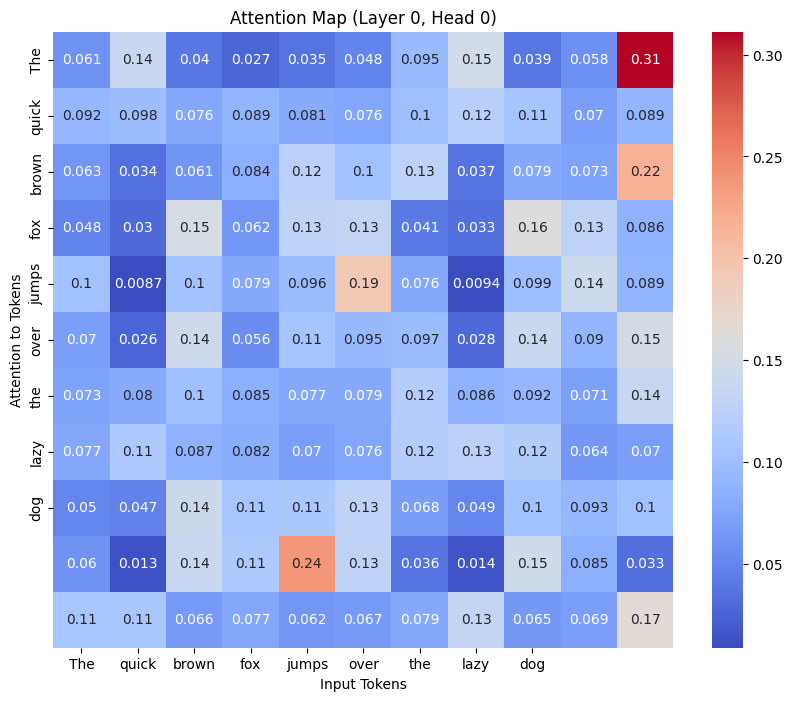

In [ ]:
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)

text = "The quick brown fox jumps over the lazy dog"
inputs = tokenizer(text, return_tensors='pt')

outputs = model(**inputs)
attentions = outputs.attentions  # Extract the attention maps

# Visualize attention for a specific layer and head (layer 0, head 0)
attention_map = attentions[0][0][0].detach().numpy()  # (num_heads, seq_len, seq_len)

plt.figure(figsize=(10, 8))
sns.heatmap(attention_map, annot=True, cmap='coolwarm', xticklabels=text.split(), yticklabels=text.split())
plt.title('Attention Map (Layer 0, Head 0)')
plt.xlabel('Input Tokens')
plt.ylabel('Attention to Tokens')
plt.show()
